In [ ]:
!pip install pyreadstat

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.6/2.6 MB 28.4 MB/s eta 0:00:00


In [ ]:
#load data and convert to pandas df
import pandas as pd

file_path = 'data.sav'
df = pd.read_spss(file_path)

# Display the first few rows of the DataFrame
print(df.head)

<bound method NDFrame.head of             IDnum   Age  Gender         VotInte VoteLabLib  \
0     2256.657690  29.0    Male  National Party        0.0   
1     4881.288746  39.0    Male  National Party        0.0   
2     6508.996105  40.0    Male  National Party        0.0   
3     3616.486364  56.0  Female  National Party        0.0   
4     2401.429928  36.0  Female  National Party        0.0   
...           ...   ...     ...             ...        ...   
5099  1310.830752  29.0  Female      Don’t know        0.0   
5100  9850.756322  37.0    Male      Don’t know        0.0   
5101  1668.575468  70.0  Female      Don’t know        0.0   
5102  1387.280950  18.0    Male      Don’t know        0.0   
5103  8122.987153  24.0  Female      Don’t know        0.0   

                                               VotMajor   PolAff  \
0                                                   N/A      NaN   
1                                                   N/A      NaN   
2                    

In [ ]:
print(df.columns.tolist())

['IDnum', 'Age', 'Gender', 'VotInte', 'VoteLabLib', 'VotMajor', 'PolAff', 'Condition', 'GWFut', 'GWImp', 'GWworry', 'GWpers', 'CCFut', 'CCImp', 'CCworry', 'CCpers', 'Important', 'Worry', 'Personal', 'Future', 'SASSYSegment']


In [ ]:
#find the most common response for each category grouped by the SASSYSegment
#Group by SASSY segment and find the mode for the specific column
target_cols = ['Important', 'Worry', 'Personal', 'Future']

#use .agg with a lambda to safely grab the first mode found for each group
segment_modes = df.groupby('SASSYSegment')[target_cols].agg(lambda x: pd.Series.mode(x)[0])

#Display results
segment_modes

,Important,Worry,Personal,Future
SASSYSegment,,,,
Alarmed,Extremely important,Very worried,A moderate amount,A great deal
Cautious,Somewhat important,Somewhat worried,Only a little,A moderate amount
Concerned,Very important,Somewhat worried,A moderate amount,A great deal
Disengaged,Somewhat important,Not very worried,Don't know,Don't know
Dismissive,Not at all important,Not at all worried,Not at all,Not at all
Doubtful,Not too important,Not very worried,Not at all,Only a little


In [ ]:
#calcalate proportions
proportions = df['SASSYSegment'].value_counts(normalize=True)
print(proportions*100)

SASSYSegment
Concerned     27.566614
Alarmed       24.862853
Cautious      23.001567
Doubtful      14.145768
Dismissive     7.327586
Disengaged     3.095611
Name: proportion, dtype: float64


In [ ]:
# Basic group by count
counts = df.groupby('SASSYSegment').size()

# Get result as a clean DataFrame with a 'count' column
counts_df = df.groupby('SASSYSegment').size().reset_index(name='counts')

print(counts_df)

  SASSYSegment  counts
0      Alarmed    1269
1     Cautious    1174
2    Concerned    1407
3   Disengaged     158
4   Dismissive     374
5     Doubtful     722


In [ ]:
!pip install plot_likert

In [ ]:
from google.colab import drive
import os

# Step 1: Mount your Drive
drive.mount('/content/drive')

# Step 2: Define your project folder path
project_folder = '/content/drive/MyDrive/BeliefSystemsProject'

# Step 3: Create the folder (does nothing if it already exists)
os.makedirs(project_folder, exist_ok=True)

Mounted at /content/drive


/usr/local/lib/python3.12/dist-packages/plot_likert/plot_likert.py:257: FutureWarning: DataFrame.applymap has been deprecated. Use DataFrame.map instead.
  df.applymap(validate)
/usr/local/lib/python3.12/dist-packages/plot_likert/plot_likert.py:310: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  responses_to_first_question = responses_per_question[0]


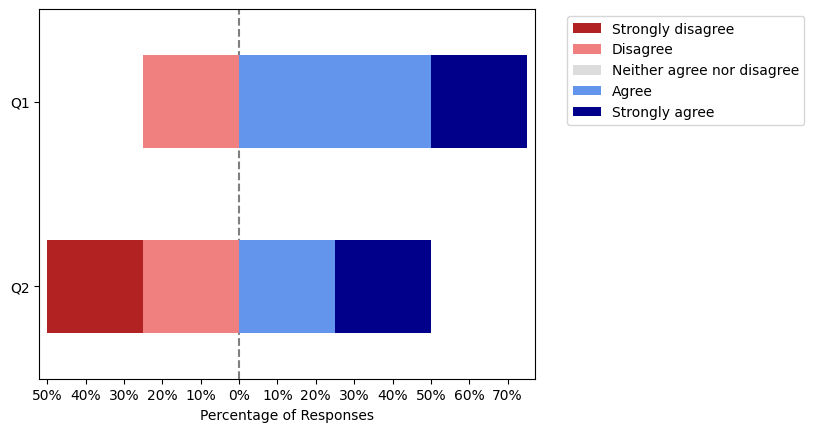

In [ ]:
import pandas as pd
import plot_likert
import matplotlib.pyplot as plt


# Sample data
data = pd.DataFrame({
    'Q1': ['Agree', 'Strongly agree', 'Disagree', 'Agree'],
    'Q2': ['Strongly disagree', 'Disagree', 'Agree', 'Strongly agree']
})

# Define your scale (standard scales are built-in)
scale = plot_likert.scales.agree

# Plot
ax = plot_likert.plot_likert(data, scale, plot_percentage=True)


# Step 4: Save figures to drive
plt.savefig(os.path.join(project_folder, 'high_res_plot.png'),
            dpi=300, bbox_inches='tight')
plt.savefig(os.path.join(project_folder, 'vector_plot.svg'))

In [ ]:
plot_likert.scales.agree

['Strongly disagree',
 'Disagree',
 'Neither agree nor disagree',
 'Agree',
 'Strongly agree']

/usr/local/lib/python3.12/dist-packages/plot_likert/plot_likert.py:257: FutureWarning: DataFrame.applymap has been deprecated. Use DataFrame.map instead.
  df.applymap(validate)


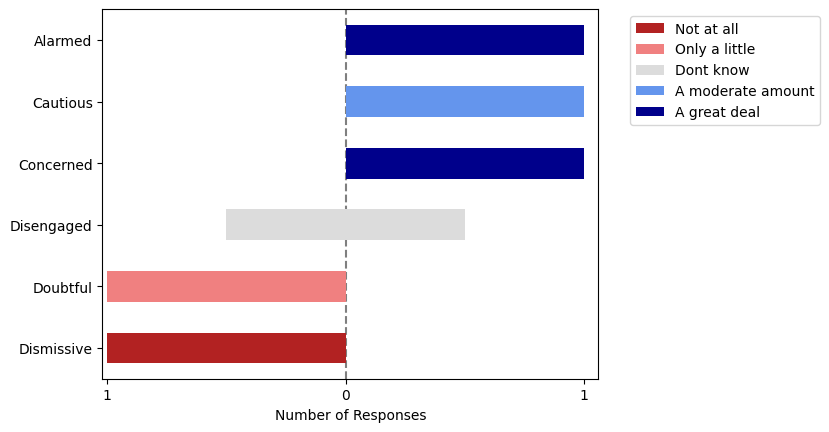

In [ ]:
import pandas as pd
import plot_likert
import matplotlib.pyplot as plt

# Sample data
data = pd.DataFrame({
    'Alarmed': ['A great deal'],
    'Cautious': ['A moderate amount'],
    'Concerned': ['A great deal'],
    'Disengaged': ['Dont know'],
    'Doubtful': ['Only a little'],
    'Dismissive': ['Not at all']
})

# Define your scale (standard scales are built-in)
scale = ['Not at all','Only a little','Dont know','A moderate amount','A great deal']

# Plot
ax = plot_likert.plot_likert(data, scale, plot_percentage=False)

# Save as a high-res PNG (300 DPI)
plt.savefig('high_res_plot.png', dpi=300, bbox_inches='tight')
# Or save as a vector file for perfect scaling
plt.savefig('vector_plot.svg')


/usr/local/lib/python3.12/dist-packages/plot_likert/plot_likert.py:257: FutureWarning: DataFrame.applymap has been deprecated. Use DataFrame.map instead.
  df.applymap(validate)


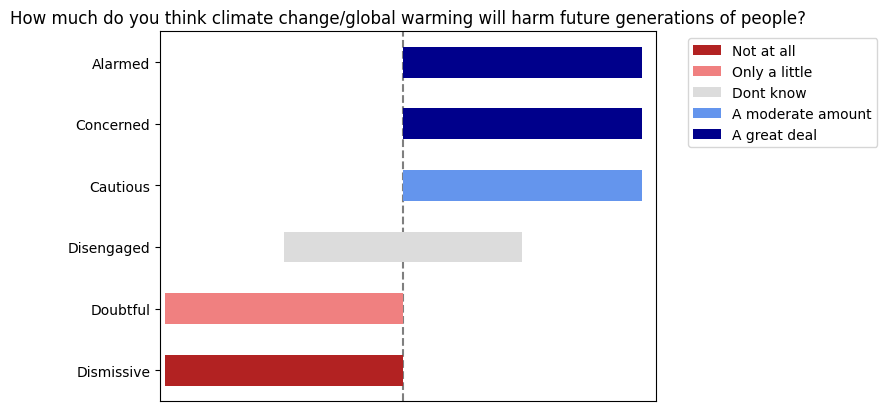

In [ ]:
#Topic 4: Future
import plot_likert
import pandas as pd # Import pandas as it's used in the sample data

# Sample data
data = pd.DataFrame({
    'Alarmed': ['A great deal'],
    'Concerned': ['A great deal'],
    'Cautious': ['A moderate amount'],
    'Disengaged': ['Dont know'],
    'Doubtful': ['Only a little'],
    'Dismissive': ['Not at all']
})

# Define your scale (standard scales are built-in)
scale = ['Not at all','Only a little','Dont know','A moderate amount','A great deal']

# Plot
ax = plot_likert.plot_likert(data, scale, plot_percentage=False)

# Remove the x-axis
ax.xaxis.set_visible(False)

# Add a title
ax.set_title('How much do you think climate change/global warming will harm future generations of people?')

# Step 4: Save figures to drive
plt.savefig(os.path.join(project_folder, 'future.png'),
            dpi=300, bbox_inches='tight')
plt.savefig(os.path.join(project_folder, 'future.svg'))

/usr/local/lib/python3.12/dist-packages/plot_likert/plot_likert.py:257: FutureWarning: DataFrame.applymap has been deprecated. Use DataFrame.map instead.
  df.applymap(validate)


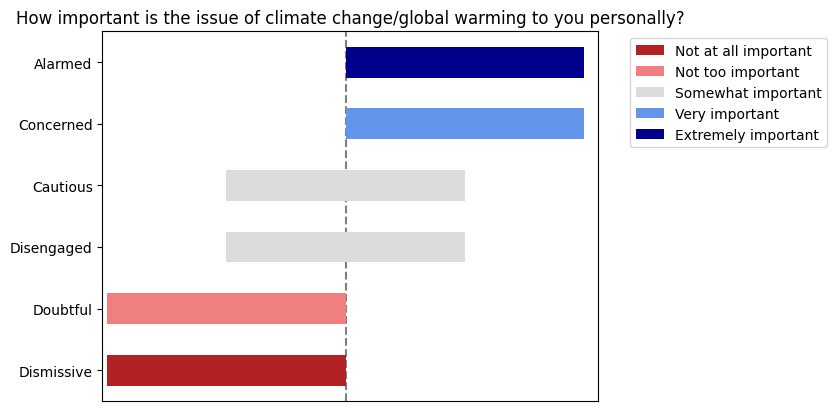

In [ ]:
#Topic 1: Important
import plot_likert
import pandas as pd # Import pandas as it's used in the sample data

# Sample data
data = pd.DataFrame({
    'Alarmed': ['Extremely important'],
    'Concerned': ['Very important'],
    'Cautious': ['Somewhat important'],
    'Disengaged': ['Somewhat important'],
    'Doubtful': ['Not too important'],
    'Dismissive': ['Not at all important']
})

# Define your scale (standard scales are built-in)
scale = ['Not at all important', 'Not too important','Somewhat important', 'Very important', 'Extremely important' ]

# Plot
ax = plot_likert.plot_likert(data, scale, plot_percentage=False)

# Remove the x-axis
ax.xaxis.set_visible(False)

# Add a title
ax.set_title('How important is the issue of climate change/global warming to you personally?')

# Step 4: Save figures to drive
plt.savefig(os.path.join(project_folder, 'important.png'),
            dpi=300, bbox_inches='tight')
plt.savefig(os.path.join(project_folder, 'important.svg'))

/usr/local/lib/python3.12/dist-packages/plot_likert/plot_likert.py:257: FutureWarning: DataFrame.applymap has been deprecated. Use DataFrame.map instead.
  df.applymap(validate)


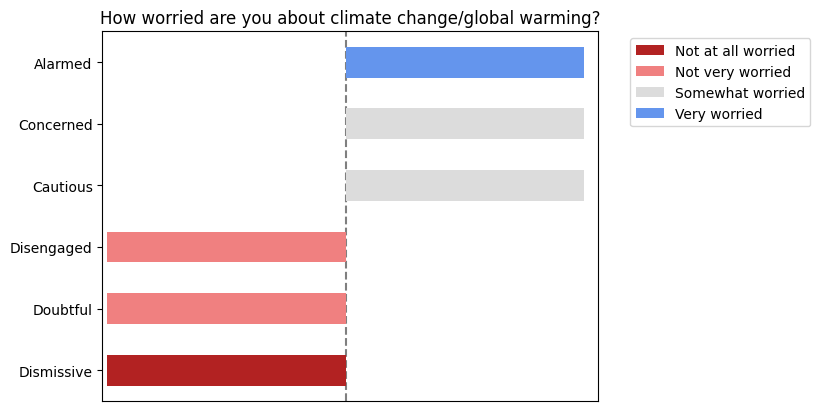

In [ ]:
#Topic 2: Worry
import plot_likert
import pandas as pd # Import pandas as it's used in the sample data

# Sample data
data = pd.DataFrame({
    'Alarmed': ['Very worried'],
    'Concerned': ['Somewhat worried'],
    'Cautious': ['Somewhat worried'],
    'Disengaged': ['Not very worried'],
    'Doubtful': ['Not very worried'],
    'Dismissive': ['Not at all worried']
})

# Define your scale (standard scales are built-in)
scale = ['Not at all worried', 'Not very worried','Somewhat worried', 'Very worried']

# Plot
ax = plot_likert.plot_likert(data, scale, plot_percentage=False)

# Remove the x-axis
ax.xaxis.set_visible(False)

# Add a title
ax.set_title('How worried are you about climate change/global warming?')

# Step 4: Save figures to drive
plt.savefig(os.path.join(project_folder, 'worry.png'),
            dpi=300, bbox_inches='tight')
plt.savefig(os.path.join(project_folder, 'worry.svg'))

/usr/local/lib/python3.12/dist-packages/plot_likert/plot_likert.py:257: FutureWarning: DataFrame.applymap has been deprecated. Use DataFrame.map instead.
  df.applymap(validate)


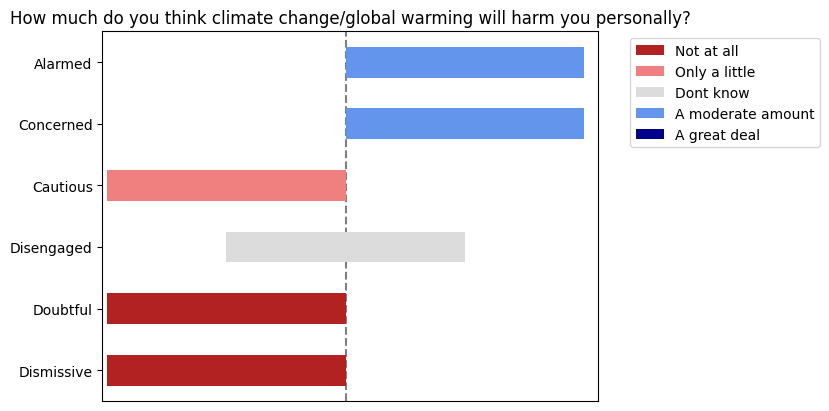

In [ ]:
#Topic 3: Personal
import plot_likert
import pandas as pd # Import pandas as it's used in the sample data

# Sample data
data = pd.DataFrame({
    'Alarmed': ['A moderate amount'],
    'Concerned': ['A moderate amount'],
    'Cautious': ['Only a little'],
    'Disengaged': ['Dont know'],
    'Doubtful': ['Not at all'],
    'Dismissive': ['Not at all']
})

# Define your scale (standard scales are built-in)
scale = ['Not at all', 'Only a little','Dont know', 'A moderate amount', 'A great deal' ]

# Plot
ax = plot_likert.plot_likert(data, scale, plot_percentage=False)

# Remove the x-axis
ax.xaxis.set_visible(False)

# Add a title
ax.set_title('How much do you think climate change/global warming will harm you personally?')

# Step 4: Save figures to drive
plt.savefig(os.path.join(project_folder, 'personal.png'),
            dpi=300, bbox_inches='tight')
plt.savefig(os.path.join(project_folder, 'personal.svg'))